In [6]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.impute import KNNImputer
from sklearn.model_selection import train_test_split
from pathlib import Path
import json
from scoit.cell_analysis import umap_visualize
from sklearn.preprocessing import MinMaxScaler

In [7]:
def save_edges_and_weights(save_dir, edges, weights, train_size, normalization):
    # Normalize 会让本来没有0的数据集产生零，即本来的最小值会变成0
    save_dir = Path(save_dir)
    nums_type = edges.max(0) + 1

    weights = weights.reshape(-1, 1)

    if normalization:
        scaler = MinMaxScaler()
        weights = scaler.fit_transform(weights)
        print('Normalize', scaler)

    train_data, test_data, train_weight, test_weight = train_test_split(edges, weights, train_size=train_size)
    train_weight = train_weight.reshape(-1)
    test_weight = test_weight.reshape(-1)

    np.savez(save_dir / 'train_data.npz', train_data=train_data, train_weight=train_weight,
             nums_type=nums_type)
    np.savez(save_dir / 'test_data.npz', test_data=test_data, test_weight=test_weight,
             nums_type=nums_type)


def save_metadata(save_dir, edges, train_size, nums_type, normalization):
    metadata = dict(
        train_size=train_size,
        normalization=normalization,
        num_edges=edges.shape[0],
        num_nodes=sum(nums_type),
        num_cells=nums_type[0],
        num_genes=nums_type[1],
        num_omics=nums_type[2],
    )
    np.savez(save_dir / 'metadata', **metadata)


In [8]:
from examples.case_studies.PEA_STA_analysis import load_data

expression_data, methylation_data, labels = load_data()

In [9]:
len(labels)

210

In [39]:
def remove_all_nan_columns(data, remove_all_zeros=True):
    print('Input #cols', data.shape[1])
    valid_cols = np.all(~np.isnan(data), axis=0)
    data = data[:, valid_cols]
    print('After remove all nan', data.shape[1])

    if remove_all_zeros:
        # 删除全是0的列。
        valid_cols = ~np.all(np.abs(data) < 1e-5, axis=0)
        data = data[:, valid_cols]
        print('After remove all zeros', data.shape[1])

    return data

In [40]:
expression_data_clean = remove_all_nan_columns(expression_data)
methylation_data_clean = remove_all_nan_columns(methylation_data)

Input #cols 141
After remove all nan 88
After remove all zeros 76
Input #cols 141
After remove all nan 78
After remove all zeros 77


Text(0.5, 1.0, 'methylation_data_clean')

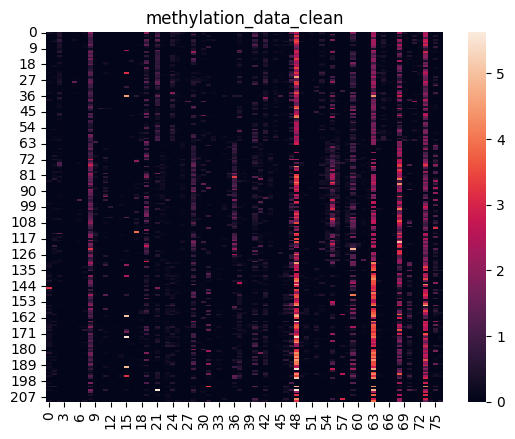

In [41]:
sns.heatmap(methylation_data_clean)
plt.title('methylation_data_clean')

Text(0.5, 1.0, 'expression_data_clean')

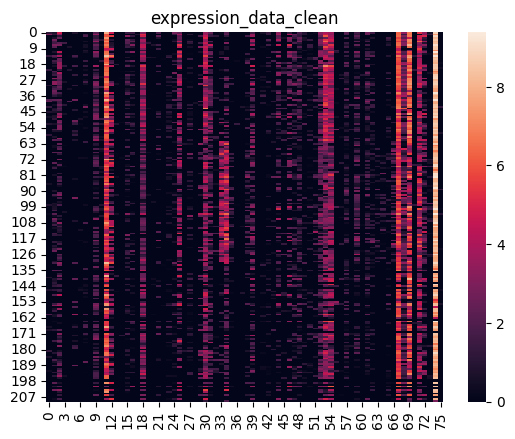

In [42]:
sns.heatmap(expression_data_clean)
plt.title('expression_data_clean')

In [43]:
def get_edges_weights_from_omics(data, omics_id, gene_offset):
    edges = np.nonzero(np.abs(data) > 1e-5)
    weights = data[edges]
    edges = edges + (np.ones_like(edges[0]) * omics_id, )
    edges = np.array(edges).T
    assert np.all(edges.max(0)[:-1] == np.array(data.shape) - 1)
    edges[:, 1] += gene_offset
    return edges, weights

In [44]:
expression_edges, expression_weights = get_edges_weights_from_omics(expression_data_clean, 0, 0)
methylation_edges, methylation_weights = get_edges_weights_from_omics(methylation_data_clean, 1, expression_data_clean.shape[1])

In [45]:
expression_edges.shape, expression_weights.shape, methylation_edges.shape, methylation_weights.shape

((5536, 3), (5536,), (4440, 3), (4440,))

In [46]:
expression_edges.max(0), methylation_edges.max(0)

(array([209,  75,   0]), array([209, 152,   1]))

In [47]:
def concat_edges_weights(edges_list, weights_list):
    return np.concatenate(edges_list, axis=0), np.concatenate(weights_list, axis=0)

In [48]:
edges, weights = concat_edges_weights([expression_edges, methylation_edges], [expression_weights, methylation_weights])

In [49]:
edges.shape, weights.shape

((9976, 3), (9976,))

In [50]:
weights.min()

0.001

In [51]:
np.any(np.abs(weights) < 1e-5)

False

In [52]:
save_edges_and_weights('./data/PEA_STA', edges=edges, weights=weights, train_size=0.8, normalization=False)

In [53]:
train_data = np.load('./data/PEA_STA/train_data.npz', allow_pickle=True)
test_data = np.load('./data/PEA_STA/test_data.npz', allow_pickle=True)

In [54]:
train_data['train_weight'].shape

(7980,)

In [55]:
np.any(np.any(train_data['train_weight'] < 1e-5))

False

In [56]:
train_data['nums_type']

array([210, 153,   2])

In [72]:
!python hgnn/main_torch_zinb.py --data PEA_STA --feature adj --loss gauss --iter 50

1.0 -0.5
model_no_randomwalk
Use train_weight (7980,)
Node type num [210 153   2]
[2.525 0.218 0.605 ... 1.43  1.836 5.566] 0.001 9.266
walk type 
adding pad idx
dict_size 7980 9976
train data amount 7980
64
tensor([  0, 210, 363, 365], device='cuda:0')
w.shape (210, 155)
(210, 155)
w.shape (153, 212)
(153, 212)
w.shape (2, 363)
(2, 363)
self.input_size [155, 212, 363]
inp 155 out 64 weight.shape torch.Size([64, 155])
fan_in 155 12.449899597988733
inp 212 out 64 weight.shape torch.Size([64, 212])
fan_in 212 14.560219778561036
inp 363 out 64 weight.shape torch.Size([64, 363])
fan_in 363 19.05255888325765
----------------------------------------------------------------
        Layer (type)               Output Shape         Param #
error MultipleEmbedding-1
 MultipleEmbedding-1           [[-1, 64], [-1]]               0
         LayerNorm-2                [-1, 3, 64]             128
         LayerNorm-3                [-1, 3, 64]             128
         LayerNorm-4                [-1, 3

In [73]:
cell_embeddings = np.load('./mymodel_0.npy', allow_pickle=True)

In [74]:
!ls -lh ./*.npy

-rw-r--r-- 1 congfeng4 mscs 53K Nov 10 14:59 ./mymodel_0.npy
-rw-r--r-- 1 congfeng4 mscs 53K Nov 10 14:59 ./mymodel_0_origin.npy
-rw-r--r-- 1 congfeng4 mscs 39K Nov 10 14:59 ./mymodel_1.npy
-rw-r--r-- 1 congfeng4 mscs 39K Nov 10 14:59 ./mymodel_1_origin.npy
-rw-r--r-- 1 congfeng4 mscs 640 Nov 10 14:59 ./mymodel_2.npy
-rw-r--r-- 1 congfeng4 mscs 640 Nov 10 14:59 ./mymodel_2_origin.npy


In [75]:
cell_embeddings.shape

(210, 64)

{'NMI': 0.5826699762749752,
 'ARI': 0.48497969707240784,
 'FMI': 0.7087092601811752}

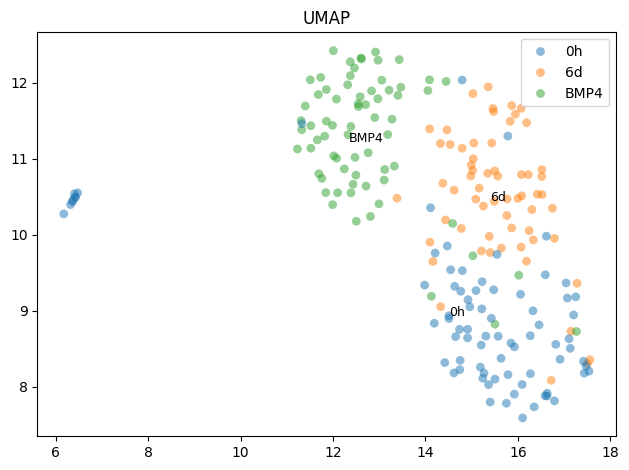

: 

In [ ]:
umap_visualize(cell_embeddings, labels)

In [77]:
!mkdir -p ./embeddings/hgnn/PEA_STA

In [78]:
!mv ./*.npy ./embeddings/hgnn/PEA_STA